# Mandelbrot Set - Numerical Scientific Computation

## Import Libraries

In [4]:
import numpy as np
from matplotlib import pyplot as plt
import time
import statistics
from numba import njit

## Naive Python Implementation

### Computation of Singular Mandelbrot Point

In [5]:
def mandelbrot_point(x, y, max_iterations, bound, power):
    c = complex(x, y)
    z = 0
    result = None

    for iteration in range(max_iterations):
        if(abs(z) >= bound):
            result = iteration
            break
        else:
            z = z**power + c
    else: # this is only called if the for loop never 'breaks'
        result = max_iterations

    return result

### Compution of Naive Mandelbrot Grid

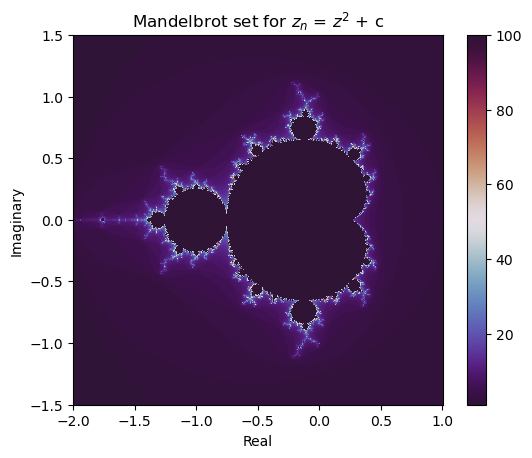

In [6]:
def compute_mandelbrot_grid(x_region, y_region, max_iterations, bound, power):
    mandelbrot_array = []

    for y_value in y_region:
        row = []
        for x_value in x_region:
            point_iteration = mandelbrot_point(x_value, y_value, max_iterations, bound, power)
            row.append(point_iteration)
        mandelbrot_array.append(row)

    return mandelbrot_array

# parameters
max_iterations = 100
bound = 2
power = 2
res = 1024

# regions
x_min, x_max = -2, 1
y_min, y_max = -1.5, 1.5
x_region = np.linspace(x_min, x_max, res)
y_region = np.linspace(y_min, y_max, res)

# compute mandelbrot
mandelbrot_array = compute_mandelbrot_grid(x_region, y_region, max_iterations, bound, power)

# plot mandelbrot
ax = plt.axes()
ax.set_aspect('equal')
graph = ax.pcolormesh(x_region, y_region, mandelbrot_array, cmap='twilight_shifted')
plt.colorbar(graph)
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.title('Mandelbrot set for $z_n$ = $z^2$ + c')
plt.show()

#### Testing the Naive Mandelbrot Grid Function

In [7]:
def test_mandelbrot_grid():
    start_time = time.perf_counter()
    mandelbrot_array = compute_mandelbrot_grid(x_region, y_region, max_iterations, bound, power)
    test_time = time.perf_counter() - start_time
    print(f'Computation took {test_time:.5f} seconds!')
    return test_time

num_samples = 5
test_times = []

for sample in range(num_samples):
    test_time = test_mandelbrot_grid()
    test_times.append(test_time)

naive_median_time = statistics.median(test_times)
print(f'Median computation time: {naive_median_time:.5f} seconds!')

Computation took 3.76812 seconds!
Computation took 3.42900 seconds!
Computation took 3.75583 seconds!
Computation took 3.72593 seconds!
Computation took 4.34210 seconds!
Median computation time: 3.75583 seconds!


## Numpy Vectorization Implementation

### Computation of Numpy Vectorized Mandelbrot Mesh

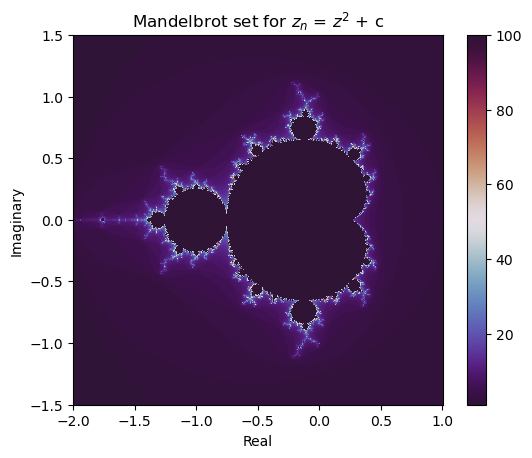

In [8]:
def compute_mandelbrot_mesh(x_region, y_region, max_iterations, bound, power):
    x_region, y_region = np.meshgrid(x_values, y_values)
    
    complex_number = 1j
    C = x_region + y_region * complex_number
    Z = np.zeros_like(C)
    M = np.zeros(C.shape, dtype=int)

    for _ in range(max_iterations):
        mask = np.abs(Z) <= bound
        Z[mask] = Z[mask]**power + C[mask]
        M[mask] += 1

    return M

# parameters
max_iterations = 100
bound = 2
power = 2
res = 1024

# regions
x_min, x_max = -2, 1
y_min, y_max = -1.5, 1.5
x_values = np.linspace(x_min, x_max, res)
y_values = np.linspace(y_min, y_max, res)

# compute mandelbrot
mandelbrot_array = compute_mandelbrot_mesh(x_region, y_region, max_iterations, bound, power)

# plot mandelbrot
ax = plt.axes()
ax.set_aspect('equal')
graph = ax.pcolormesh(x_region, y_region, mandelbrot_array, cmap='twilight_shifted')
plt.colorbar(graph)
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.title(f'Mandelbrot set for $z_n$ = $z^{power}$ + c')
plt.show()

#### Testing Numpy Vectorized Mandelbrot Mesh

In [9]:
def test_mandelbrot_mesh():
    start_time = time.perf_counter()
    mandelbrot_array = compute_mandelbrot_mesh(x_region, y_region, max_iterations, bound, power)
    test_time = time.perf_counter() - start_time
    print(f'Computation took {test_time:.5f} seconds!')
    return test_time

num_samples = 5
test_times = []

for sample in range(num_samples):
    test_time = test_mandelbrot_mesh()
    test_times.append(test_time)

numpy_median_time = statistics.median(test_times)
print(f'Median computation time: {numpy_median_time:.5f} seconds!')

Computation took 1.75793 seconds!
Computation took 1.84872 seconds!
Computation took 1.47725 seconds!
Computation took 1.23130 seconds!
Computation took 1.29238 seconds!
Median computation time: 1.47725 seconds!


## Numba Optimization Implementation

### Computation of the Numba Optimized Mandelbrot Grid

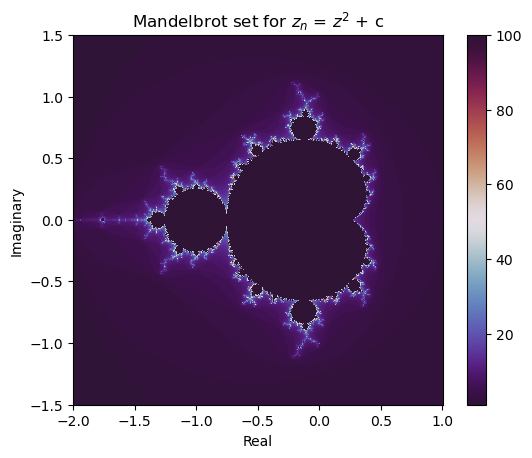

In [10]:
@njit
def compute_numba_naive_mandelbrot(x_region, y_region, max_iterations, bound, power, res):
    result = np.zeros((res,res), dtype=np.int32)

    for i in range(res):
        for j in range(res):
            c = x_region[j] + y_region[i] * 1j
            z = 0j
            n = 0

            while n < max_iterations and z.real*z.real + z.imag*z.imag <= bound*bound:
                z = z*z + c
                n += 1
            result[i,j] = n

    return result

# parameters
max_iterations = 100
bound = 2
power = 2
res = 1024

# regions
x_min, x_max = -2, 1
y_min, y_max = -1.5, 1.5
x_region = np.linspace(x_min, x_max, res)
y_region = np.linspace(y_min, y_max, res)

# compute mandelbrot
mandelbrot_array = compute_numba_naive_mandelbrot(x_region, y_region, max_iterations, bound, power, res)

# plot mandelbrot
ax = plt.axes()
ax.set_aspect('equal')
graph = ax.pcolormesh(x_region, y_region, mandelbrot_array, cmap='twilight_shifted')
plt.colorbar(graph)
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.title('Mandelbrot set for $z_n$ = $z^2$ + c')
plt.show()

### Testing Numba Optimized Mandelbrot Grid

In [12]:
def test_numba_mandelbrot_grid():
    start_time = time.perf_counter()
    mandelbrot_array = compute_numba_naive_mandelbrot(x_region, y_region, max_iterations, bound, power, res)
    test_time = time.perf_counter() - start_time
    print(f'Computation took {test_time:.5f} seconds!')
    return test_time

num_samples = 5
test_times = []

for sample in range(num_samples):
    test_time = test_numba_mandelbrot_grid()
    test_times.append(test_time)

numba_median_time = statistics.median(test_times)
print(f'Median computation time: {numba_median_time:.5f} seconds!')

Computation took 0.06693 seconds!
Computation took 0.05399 seconds!
Computation took 0.05018 seconds!
Computation took 0.05063 seconds!
Computation took 0.04981 seconds!
Median computation time: 0.05063 seconds!


## Comparison of Implementations

In [14]:
print(f'Naive: {naive_median_time:.5f} s')

print(f'Numpy: {numpy_median_time:.5f} s')
weekly_speedup = naive_median_time / numpy_median_time
print(f'Weekly Speedup: {weekly_speedup:.2f}x')

print(f'Numba: {numba_median_time:.5f} s')
weekly_speedup = numpy_median_time / numba_median_time
print(f'Weekly Speedup: {weekly_speedup:.2f}x')
total_speedup = naive_median_time / numba_median_time
print(f'Total Speedup: {total_speedup:.2f}x')

Naive: 3.75583 s
Numpy: 1.47725 s
Weekly Speedup: 2.54x
Numba: 0.05063 s
Weekly Speedup: 29.18x
Total Speedup: 74.19x
